# Vendor Performance Analysis

**Goal:** figure out which vendors and brands are helping (or hurting) profitability, and give concrete, data-backed recommendations.

This notebook picks up where the data pipeline (`01_data_pipeline.ipynb`) leaves off. That step joins purchase, sales and freight data into one table — `vendor_sales_summary` — and saves it as `data/vendor_sales_summary.csv`. Everything below works from that single file, so this notebook runs standalone.

**How to read this notebook:** each section starts with the plain-English question being asked, followed by the code and chart that answers it, followed by a one-line takeaway.


## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

sns.set_style("whitegrid")
%matplotlib inline


## 2. Load the data

In [1]:
df = pd.read_csv("../data/vendor_sales_summary.csv")
print(df.shape)
df.head()


(10692, 18)


## 3. Quick look at the data

Before answering business questions, check for anything that would skew the results: missing values, wrong data types, and outliers.

In [1]:
df.describe().T


# summary statistics for all numeric columns


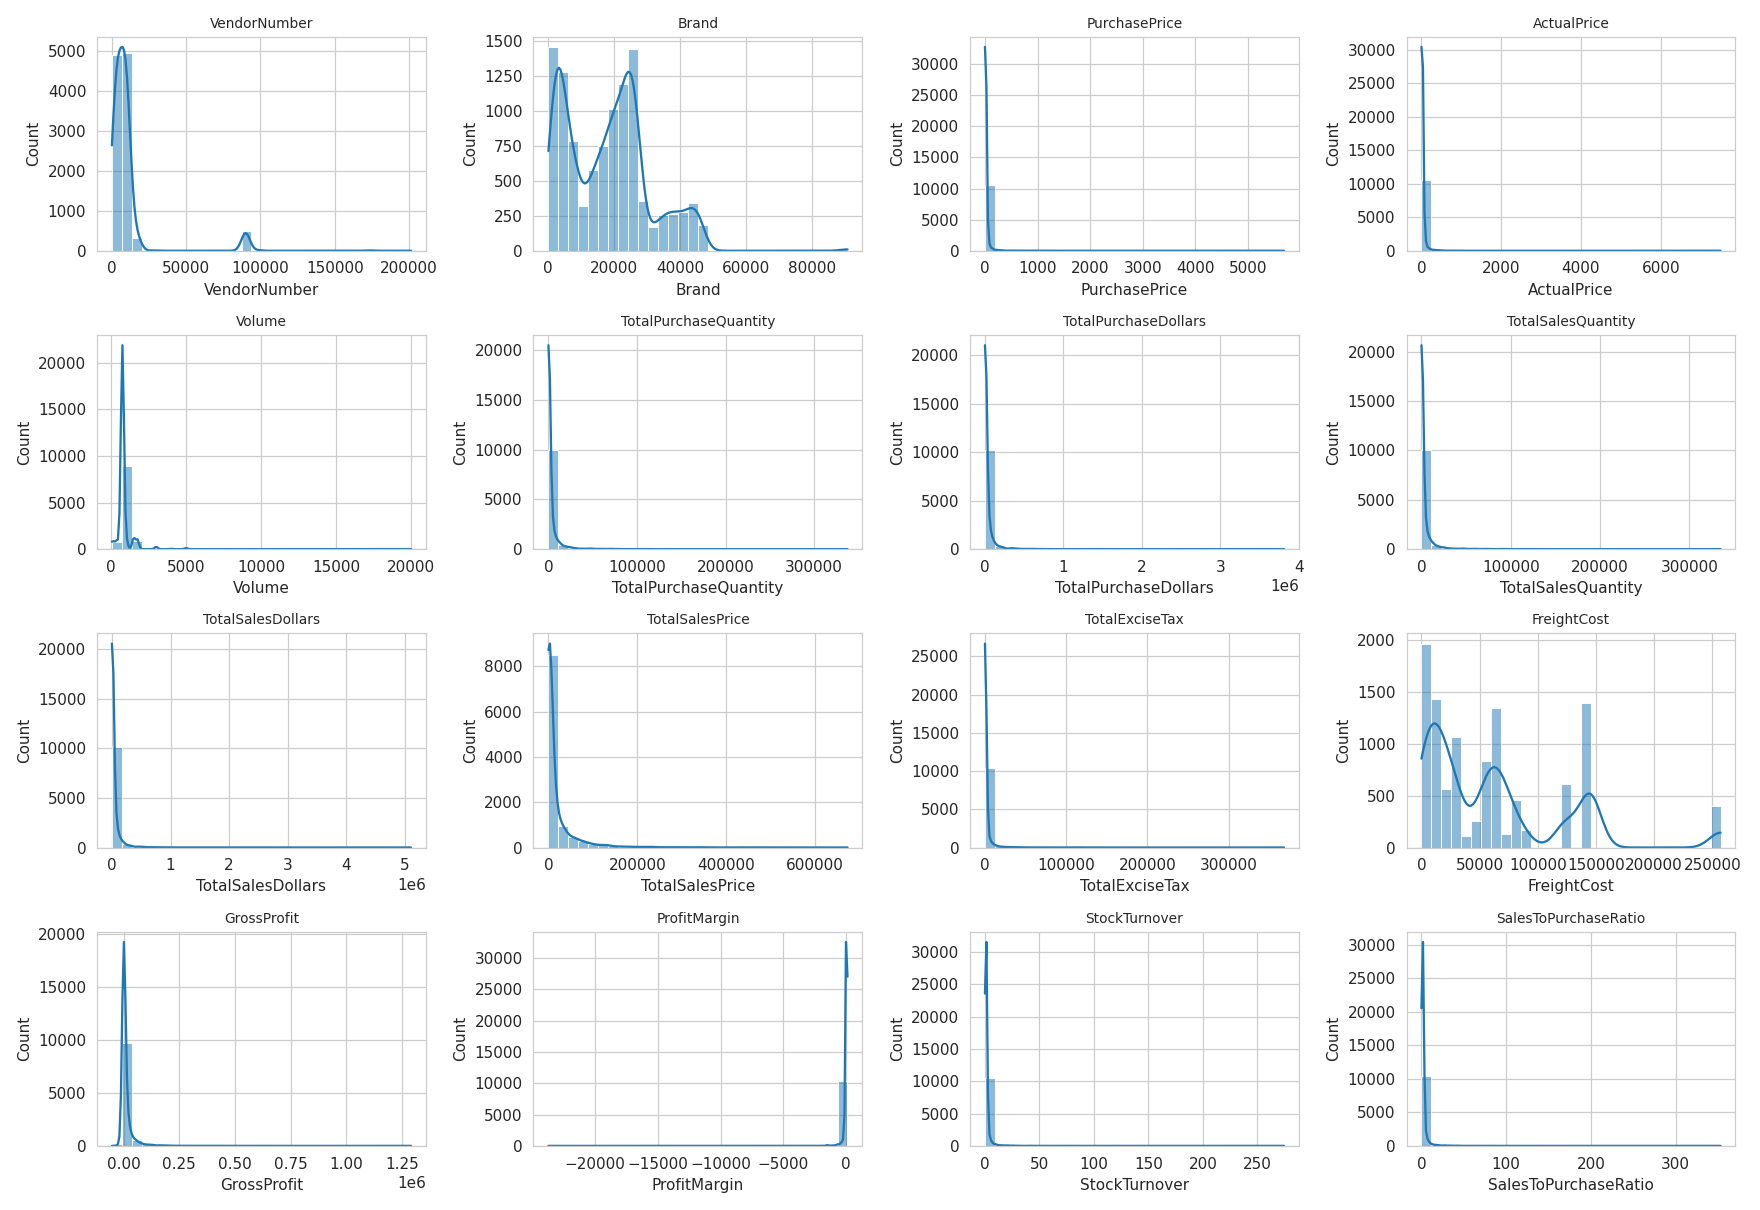

In [1]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(4, 4, figsize=(16, 11))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], kde=True, bins=30, ax=ax)
    ax.set_title(col, fontsize=9)
for ax in axes.flat[len(num_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.show()


**What this shows:**
- `GrossProfit` has a minimum of about **-52,000** — some products are being sold at a loss.
- `ProfitMargin` goes as low as **-∞**, which happens when a product had $0 in sales but still had a purchase cost.
- Several products show **zero sales** entirely — purchased but never sold (dead stock).

None of these are data errors — they're real business situations — but they'd distort averages if left in. The fix: filter them out before doing the profitability analysis, and treat them as their own finding (dead stock, loss-making SKUs) rather than noise.

In [1]:
# Keep only transactions that reflect a normal, profitable sale
df = df[(df["GrossProfit"] > 0) & (df["ProfitMargin"] > 0) & (df["TotalSalesQuantity"] > 0)].copy()
df.shape


(8565, 18)


### Correlation check

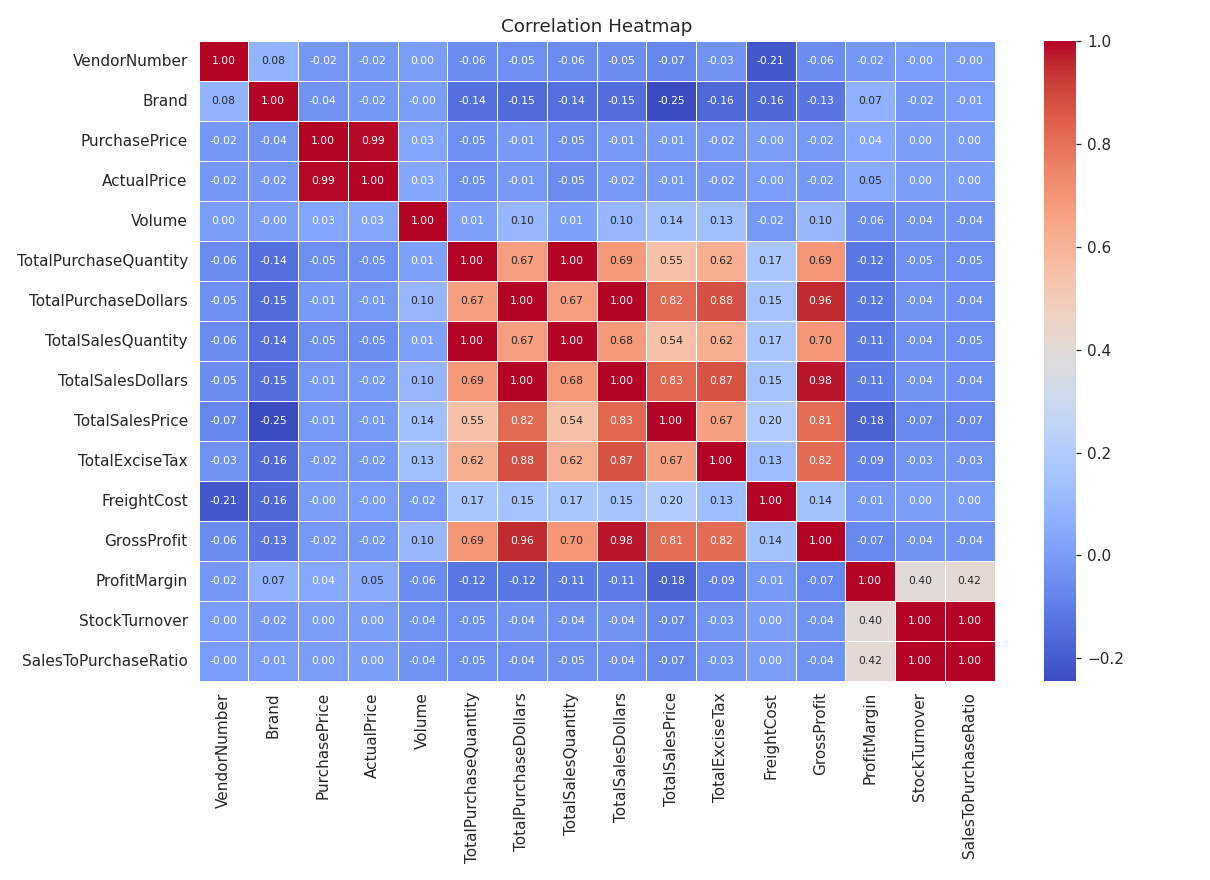

In [1]:
plt.figure(figsize=(11, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.4, annot_kws={"size": 7})
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


**Takeaway:** `PurchasePrice` barely correlates with sales or profit (~-0.01), meaning higher-priced products aren't inherently more or less profitable. `TotalPurchaseQuantity` and `TotalSalesQuantity` move almost perfectly together (0.999) — inventory isn't piling up in aggregate, even though (as we'll see) it is for specific vendors.

## 4. Which brands need a pricing or promotion push?

**Question:** are there brands with a healthy profit margin that just aren't selling much? Those are good promotion candidates — the margin is already there, they just need more volume.

In [1]:
brand_perf = df.groupby("Description").agg(
    TotalSalesDollars=("TotalSalesDollars", "sum"),
    ProfitMargin=("ProfitMargin", "mean")
).reset_index()

# "low sales" = bottom 15%, "high margin" = top 15%
low_sales_thr = brand_perf["TotalSalesDollars"].quantile(0.15)
high_margin_thr = brand_perf["ProfitMargin"].quantile(0.85)

target_brands = brand_perf[
    (brand_perf["TotalSalesDollars"] <= low_sales_thr) &
    (brand_perf["ProfitMargin"] >= high_margin_thr)
]
print(f"{len(target_brands)} brands flagged")
target_brands.sort_values("TotalSalesDollars").head(10)


198 brands flagged


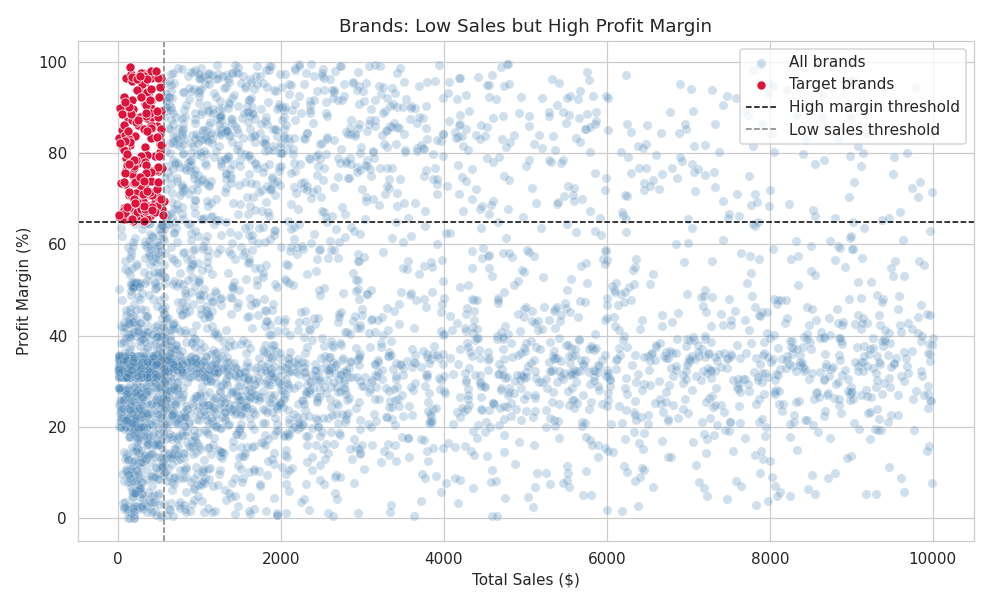

In [1]:
plot_df = brand_perf[brand_perf["TotalSalesDollars"] < 10000]

plt.figure(figsize=(9, 5.5))
sns.scatterplot(data=plot_df, x="TotalSalesDollars", y="ProfitMargin", color="steelblue", alpha=0.25, label="All brands")
sns.scatterplot(data=target_brands[target_brands["TotalSalesDollars"] < 10000], x="TotalSalesDollars", y="ProfitMargin", color="crimson", label="Target brands")
plt.axhline(high_margin_thr, linestyle="--", color="black", linewidth=1, label="High margin threshold")
plt.axvline(low_sales_thr, linestyle="--", color="grey", linewidth=1, label="Low sales threshold")
plt.title("Brands: Low Sales but High Profit Margin")
plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.legend()
plt.tight_layout()
plt.show()


**Takeaway:** 198 brands sit in the red zone — low sales, high margin. These are the best promotion candidates: the profitability is already proven, they just need visibility.

## 5. Which vendors matter most?

**Question:** how concentrated is the business among vendors? Relying too heavily on a small number is a supply-chain risk.

In [1]:
def fmt_dollars(v):
    if v >= 1_000_000: return f"{v/1_000_000:.2f}M"
    if v >= 1_000: return f"{v/1_000:.2f}K"
    return str(round(v, 2))

vendor_perf = df.groupby("VendorName").agg(
    TotalPurchaseDollars=("TotalPurchaseDollars", "sum"),
    TotalSalesDollars=("TotalSalesDollars", "sum"),
    GrossProfit=("GrossProfit", "sum"),
).reset_index()
vendor_perf["Purchase_Contribution%"] = (vendor_perf["TotalPurchaseDollars"] / vendor_perf["TotalPurchaseDollars"].sum()) * 100

top_vendors = vendor_perf.sort_values("Purchase_Contribution%", ascending=False).head(10).reset_index(drop=True)
top10_total = top_vendors["Purchase_Contribution%"].sum()
print(f"Top 10 vendors = {top10_total:.2f}% of all purchases")
top_vendors[["VendorName", "Purchase_Contribution%"]]


Top 10 vendors = 65.69% of all purchases


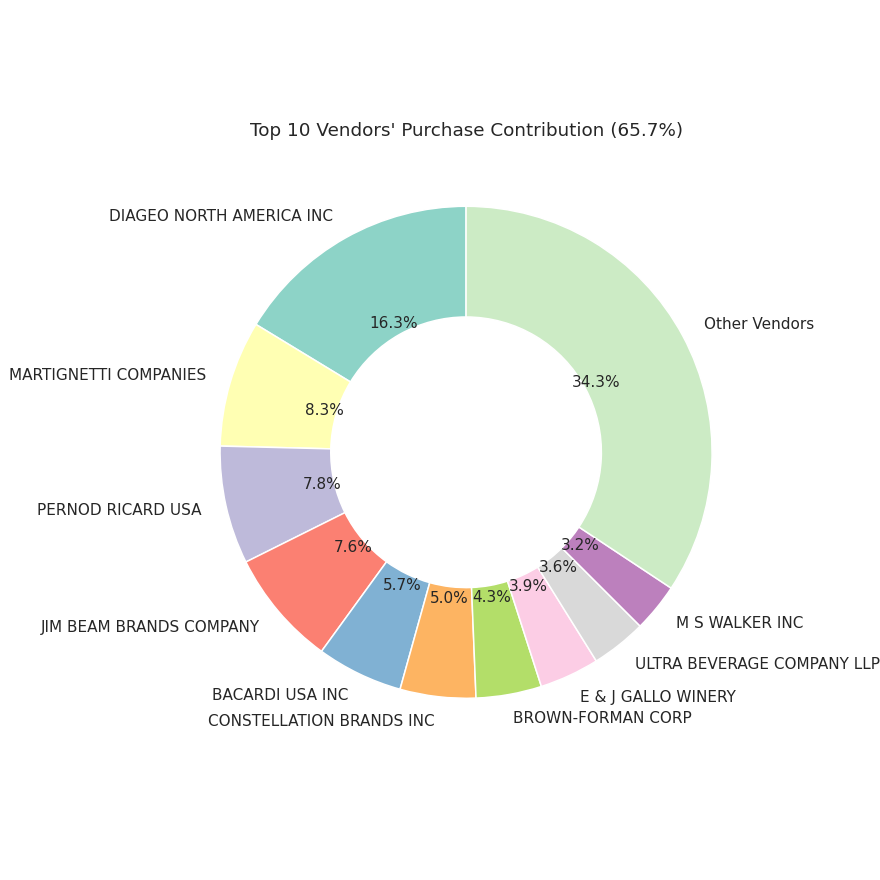

In [1]:
labels = list(top_vendors["VendorName"]) + ["Other Vendors"]
sizes = list(top_vendors["Purchase_Contribution%"]) + [100 - top10_total]

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90,
        colors=sns.color_palette("Set3", len(labels)), wedgeprops=dict(width=0.45))
plt.title(f"Top 10 Vendors' Purchase Contribution ({top10_total:.1f}%)")
plt.tight_layout()
plt.show()


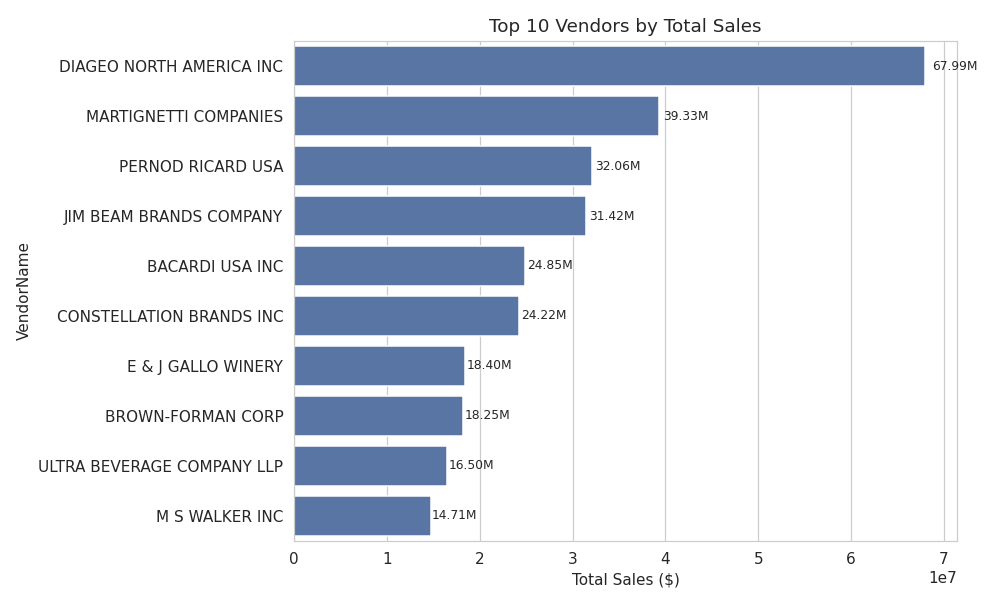

In [1]:
top_sales_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)

plt.figure(figsize=(9, 5.5))
ax = sns.barplot(y=top_sales_vendors.index, x=top_sales_vendors.values, color="#4C72B0")
for bar in ax.patches:
    ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2, fmt_dollars(bar.get_width()), va="center", fontsize=8)
plt.title("Top 10 Vendors by Total Sales")
plt.xlabel("Total Sales ($)")
plt.tight_layout()
plt.show()


**Takeaway:** 10 vendors account for **65.7%** of all purchases; the other 34.3% is spread across the rest. That's a meaningful concentration risk — losing one top vendor would hurt significantly more than losing any single 'other' vendor.

## 6. Does buying in bulk actually lower the unit cost?

**Question:** is there a real cost benefit to larger purchase orders, and how big is it?

In [1]:
df["UnitPurchasePrice"] = df["TotalPurchaseDollars"] / df["TotalPurchaseQuantity"]
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels=["Small", "Medium", "Large"])

bulk = df.groupby("OrderSize", observed=True)["UnitPurchasePrice"].mean()
pct_reduction = (1 - bulk["Large"] / bulk["Small"]) * 100
print(bulk)
print(f"\nLarge vs Small order unit cost reduction: {pct_reduction:.1f}%")


OrderSize
Small     39.057543
Medium    15.486414
Large     10.777625
Name: UnitPurchasePrice, dtype: float64

Large vs Small order unit cost reduction: 72.4%


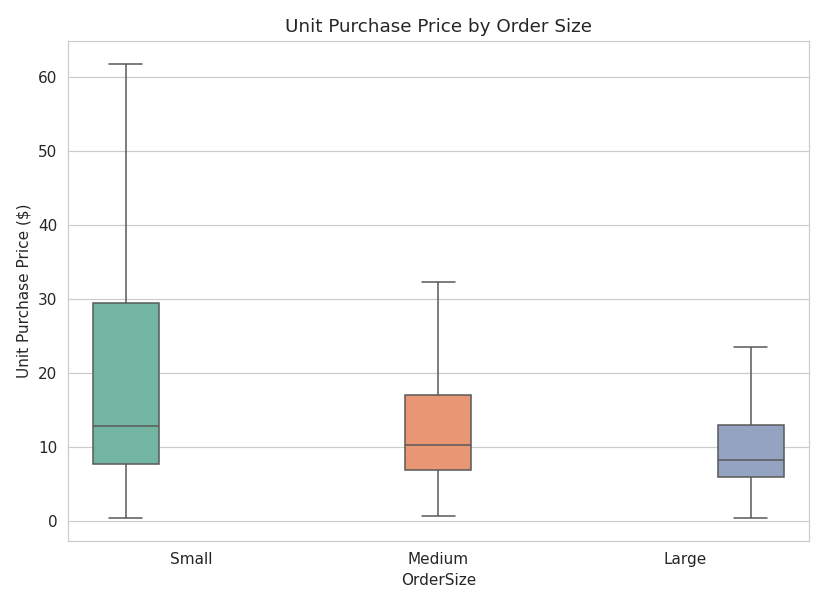

In [1]:
plt.figure(figsize=(7.5, 5.5))
sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", hue="OrderSize", palette="Set2", legend=False, showfliers=False)
plt.title("Unit Purchase Price by Order Size")
plt.ylabel("Unit Purchase Price ($)")
plt.tight_layout()
plt.show()


**Takeaway:** large orders cost **72% less per unit** than small orders ($10.78 vs $39.06). Bulk buying is clearly worth it — as long as the resulting inventory actually sells (see next section).

## 7. Who's sitting on unsold inventory?

**Question:** bulk buying saves money per unit, but only if the stock moves. Which vendors have slow-moving inventory, and how much cash is tied up in it?

In [1]:
low_turnover = (df[df["StockTurnover"] < 1]
                .groupby("VendorName")["StockTurnover"].mean()
                .sort_values().reset_index())
low_turnover.head(10)


# 10 vendors with the slowest-moving stock (StockTurnover < 1)


In [1]:
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["PurchasePrice"]
total_unsold = df["UnsoldInventoryValue"].sum()
print("Total capital tied up in unsold inventory:", fmt_dollars(total_unsold))

df.groupby("VendorName")["UnsoldInventoryValue"].sum().sort_values(ascending=False).head(10).apply(fmt_dollars)


Total capital tied up in unsold inventory: 2.71M


**Takeaway:** **$2.71M** is currently tied up in unsold stock. It's concentrated among the same large vendors (Diageo, Jim Beam, Pernod Ricard) — which makes sense, since they also have the largest order volumes. Worth a targeted clearance push rather than a blanket policy.

## 8. Do high-margin and low-margin vendors actually differ, or is it noise?

**Question:** low-performing vendors *look* like they have higher margins than top vendors — but is that a real, statistically meaningful pattern, or could it just be random variation?

In [1]:
top_thr = df["TotalSalesDollars"].quantile(0.75)
low_thr = df["TotalSalesDollars"].quantile(0.25)

top_v = df[df["TotalSalesDollars"] >= top_thr]["ProfitMargin"].dropna()
low_v = df[df["TotalSalesDollars"] <= low_thr]["ProfitMargin"].dropna()

def ci95(s):
    m = s.mean()
    se = s.std() / np.sqrt(len(s))
    return m - 1.96*se, m + 1.96*se, m

top_lo, top_hi, top_mean = ci95(top_v)
low_lo, low_hi, low_mean = ci95(low_v)

print(f"Top vendors    -> 95% CI: ({top_lo:.2f}%, {top_hi:.2f}%), mean = {top_mean:.2f}%")
print(f"Low vendors    -> 95% CI: ({low_lo:.2f}%, {low_hi:.2f}%), mean = {low_mean:.2f}%")


Top vendors    -> 95% CI: (30.74%, 31.61%), mean = 31.17%
Low vendors    -> 95% CI: (40.48%, 42.62%), mean = 41.55%


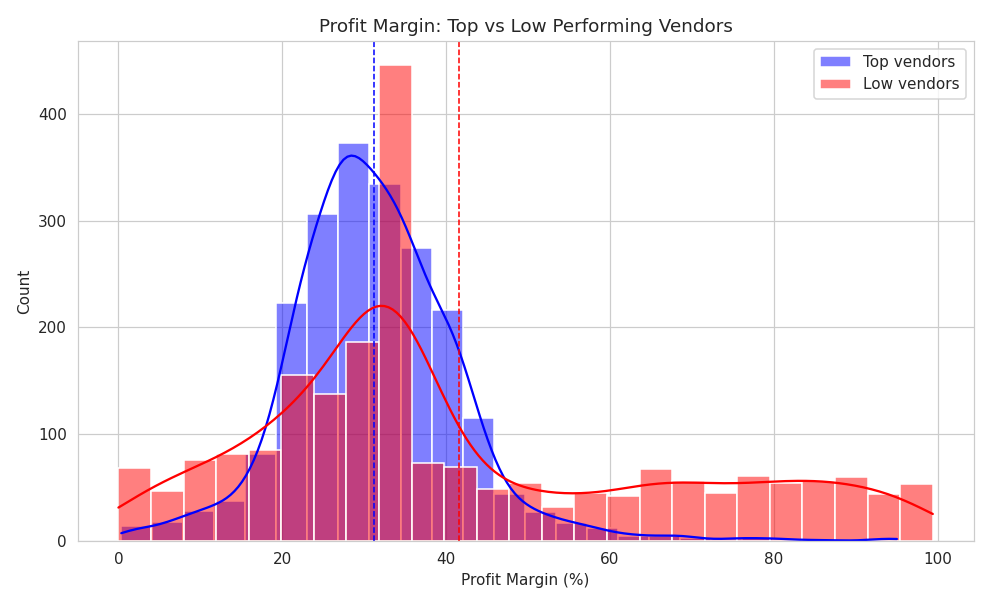

In [1]:
plt.figure(figsize=(9, 5.5))
sns.histplot(top_v, kde=True, color="blue", label="Top vendors", alpha=0.5, bins=25)
sns.histplot(low_v, kde=True, color="red", label="Low vendors", alpha=0.5, bins=25)
plt.axvline(top_mean, color="blue", linestyle="--", linewidth=1)
plt.axvline(low_mean, color="red", linestyle="--", linewidth=1)
plt.title("Profit Margin: Top vs Low Performing Vendors")
plt.xlabel("Profit Margin (%)")
plt.legend()
plt.tight_layout()
plt.show()


**Hypothesis test:**
- H0: no real difference in mean profit margin between top and low vendors
- H1: there is a real difference

Since the two groups aren't the same size and may have different variances, a Welch's t-test (which doesn't assume equal variance) is the right tool here.

In [1]:
t_stat, p_value = ttest_ind(top_v, low_v, equal_var=False)
print(f"t-statistic = {t_stat:.3f}")
print(f"p-value     = {p_value:.2e}")


t-statistic = -17.644
p-value     = 3.98e-66


**Takeaway:** the p-value is far below 0.05, so we reject H0. The confidence intervals don't overlap and the gap is large (~10 points) — top-selling vendors run on thinner margins, low-volume vendors run on fatter ones. This isn't noise; it's two different pricing strategies.

## 9. Summary of findings

| # | Finding | Number |
|---|---------|--------|
| 1 | Brands with low sales but high margin (promo candidates) | 198 brands |
| 2 | Purchase concentration in top 10 vendors | 65.7% |
| 3 | Unit cost reduction from bulk (large vs small) orders | 72% ($39.06 → $10.78) |
| 4 | Capital tied up in unsold inventory | $2.71M |
| 5 | Profit margin gap, low vs top vendors (statistically significant, p < 0.001) | 41.6% vs 31.2% |

## 10. Recommendations

- **Promote, don't discount** the 198 low-sales/high-margin brands — the margin is already there.
- **Diversify vendor base.** 65.7% purchase concentration in 10 vendors is a real supply-chain risk; start qualifying 2-3 backup vendors for the top categories.
- **Keep buying in bulk**, but pair it with a **demand forecast** so the 72% unit-cost saving doesn't turn into more of the $2.71M dead-stock problem.
- **Run a clearance push** targeted at the specific low-turnover vendors identified above, rather than a blanket inventory discount.
- **Rethink pricing for top vendors.** Their margins are ~10 points thinner than low-volume vendors; a small, targeted price adjustment on their best sellers could recover meaningful profit without hurting volume.

## 11. Limitations & how this could be improved

- This is a **snapshot in time** — there's no date dimension in the summary table, so trends over time (seasonality, growth) aren't visible. Adding a monthly grain would unlock that.
- "Vendor performance" here is judged mostly on margin and volume. Adding **on-time delivery / lead-time data** (if available in `vendor_invoice`) would make the vendor-risk story more complete.
- The 15%/85% and quartile thresholds used above are reasonable defaults, not optimized — worth testing sensitivity to different cutoffs.
- Outlier filtering (`GrossProfit > 0` etc.) removes real transactions (returns, dead stock) from the *profitability* analysis. They're worth analyzing separately rather than only discarding — a natural next notebook.
- A regression or clustering model (e.g. segmenting vendors by margin + volume + turnover) would turn this from descriptive analysis into something predictive.
